In [42]:
# Project Scenario: Smart Waste Classification System
# A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:
#     Recyclable Waste
#     Organic Waste
#     Non-Recyclable Waste
# You are required to build a deep learning image classifier that can perform this task.
# Task 1 – Dataset Collection (5 Marks)
#     Download or collect a dataset of waste images from sources 
# https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com
#     Organize the dataset into the following folder structure:
# dataset/
#    train/
#        recyclable/
#        organic/
#        non_recyclable/
#    validation/
#        recyclable/
#        organic/
#        non_recyclable/
# Deliverable:
# • Show the dataset structure and total number of images in each class.
# Task 2 – Data Preprocessing (5 Marks)
# Perform the following preprocessing steps:
#     Resize images to a fixed size (e.g., 224×224)
#     Normalize pixel values
#     Apply data augmentation (at least 3 techniques)
# Examples:
#     Rotation
#     Horizontal flip
#     Zoom
#     Brightness adjustment
# Deliverable:
# • Show the preprocessing pipeline code.
# Task 3 – CNN Model Development (8 Marks)
# Build an image classification model using CNN.
# Your model should include:
#     Convolution layers
#     Pooling layers
#     Dense layers
#     Softmax output layer
# Train the model and display:
#     Training accuracy
#     Validation accuracy
#     Training loss curve
# Deliverable:
# • Model architecture
# • Training output
# • Accuracy graph
# Task 4 – Model Evaluation (6 Marks)
# Evaluate the trained model using:
#     Confusion Matrix
#     Accuracy score
#     Sample predictions on test images
# Deliverable:
# • Confusion matrix visualization
# • 5 test image predictions with predicted labels
# Task 5 – Transfer Learning Implementation (6 Marks)
# Improve your system by implementing Transfer Learning using a pretrained model such as:
#     ResNet50
#     MobileNetV2
#     VGG16
# Steps:
#     Load a pretrained model
#     Freeze base layers
#     Add custom classification layers
#     Train the model
# Compare results with your original CNN model.
# Deliverable:
# • Accuracy comparison between Custom CNN vs Transfer Learning model

In [4]:
                                                  # TASK 1
import os
import random
import shutil

train_path = "train"
validation_path = "validation"

classes = ["recyclable", "non_recyclable", "organic"]

for cls in classes:

    train_class_path = os.path.join(train_path, cls)
    val_class_path = os.path.join(validation_path, cls)

    images = os.listdir(train_class_path)

    random.shuffle(images)

    split = int(0.2 * len(images))
    val_images = images[:split]

    for img in val_images:
        src = os.path.join(train_class_path, img)
        dst = os.path.join(val_class_path, img)
        shutil.move(src, dst)

    print(cls, ":", len(val_images), "images moved to validation")

recyclable : 478 images moved to validation
non_recyclable : 27 images moved to validation
organic : 0 images moved to validation


In [5]:
!pip install bing-image-downloader

In [7]:
!pip install icrawler


   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   ---------------------------------------- 2/2 [icrawler]



In [8]:
from icrawler.builtin import BingImageCrawler

crawler = BingImageCrawler(storage={'root_dir': 'train/organic'})

crawler.crawl(
    keyword='organic waste food scraps compost',
    max_num=150
)

print("Organic waste images downloaded successfully")

2026-03-14 14:57:32,212 - INFO - icrawler.crawler - start crawling...
2026-03-14 14:57:32,213 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-03-14 14:57:32,216 - INFO - icrawler.crawler - starting 1 parser threads...
2026-03-14 14:57:32,219 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-03-14 14:57:33,441 - INFO - parser - parsing result page https://www.bing.com/images/async?q=organic waste food scraps compost&first=0
2026-03-14 14:57:34,936 - INFO - downloader - image #1	https://as2.ftcdn.net/v2/jpg/06/77/29/59/1000_F_677295908_a8YPOv3oaZiTOnMjqqkUUfFUIP4IGJWR.jpg
2026-03-14 14:57:35,427 - INFO - downloader - image #2	https://as2.ftcdn.net/v2/jpg/06/77/29/73/1000_F_677297365_aJkBK9DsB9FshoLkgiZ7aVxcarY5zEk6.jpg
2026-03-14 14:57:36,432 - INFO - downloader - image #3	https://as1.ftcdn.net/v2/jpg/05/28/64/08/1000_F_528640817_so3QcLOIUWsso0q02mXBEfCDiQNLmgsA.jpg
2026-03-14 14:57:36,684 - INFO - downloader - image #4	https://as1.ftcdn.net/v2/jpg/07/08/96/

Organic waste images downloaded successfully


2026-03-14 14:59:14,789 - ERROR - parser - Exception caught when fetching page https://www.bing.com/images/async?q=organic waste food scraps compost&first=80, error: HTTPSConnectionPool(host='www.bing.com', port=443): Read timed out. (read timeout=5), remaining retry times: 0
2026-03-14 14:59:16,805 - INFO - parser - no more page urls for thread parser-001 to parse
2026-03-14 14:59:16,808 - INFO - parser - thread parser-001 exit


In [9]:
import os

classes = ["recyclable", "organic", "non_recyclable"]

print("TRAIN DATASET")
for cls in classes:
    path = os.path.join("train", cls)
    print(cls, ":", len(os.listdir(path)), "images")

print("\nVALIDATION DATASET")
for cls in classes:
    path = os.path.join("validation", cls)
    print(cls, ":", len(os.listdir(path)), "images")

TRAIN DATASET
recyclable : 1912 images
organic : 39 images
non_recyclable : 110 images

VALIDATION DATASET
recyclable : 478 images
organic : 11 images
non_recyclable : 27 images


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          
    rotation_range=20,        
    horizontal_flip=True,     
    zoom_range=0.2,           
    brightness_range=[0.8,1.2] 
)

In [12]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(
    "train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 2061 images belonging to 3 classes.


In [14]:
validation_generator = validation_datagen.flow_from_directory(
    "validation",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 516 images belonging to 3 classes.


In [15]:
print(train_generator.class_indices)

{'non_recyclable': 0, 'organic': 1, 'recyclable': 2}


In [ ]:
#                                  TASK 3

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [17]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(3, activation='softmax'))

D:\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.9146 - loss: 0.4213 - val_accuracy: 0.9264 - val_loss: 0.3232
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 296s 4s/step - accuracy: 0.9301 - loss: 0.2710 - val_accuracy: 0.9264 - val_loss: 0.3253
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.9248 - loss: 0.2843 - val_accuracy: 0.9302 - val_loss: 0.2496
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.9316 - loss: 0.2480 - val_accuracy: 0.9380 - val_loss: 0.2146
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.9355 - loss: 0.2265 - val_accuracy: 0.9360 - val_loss: 0.2457
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 292s 4s/step - accuracy: 0.9345 - loss: 0.2475 - val_accuracy: 0.9399 - val_loss: 0.2299
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.9345 - loss: 0.2347 - val_accuracy: 0.8934 - val_loss: 0.3187
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.9364 - loss: 0.2255 - val_accuracy: 0.9012 - v

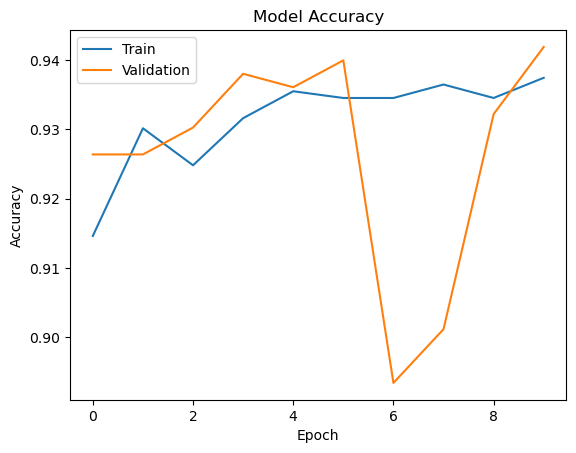

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

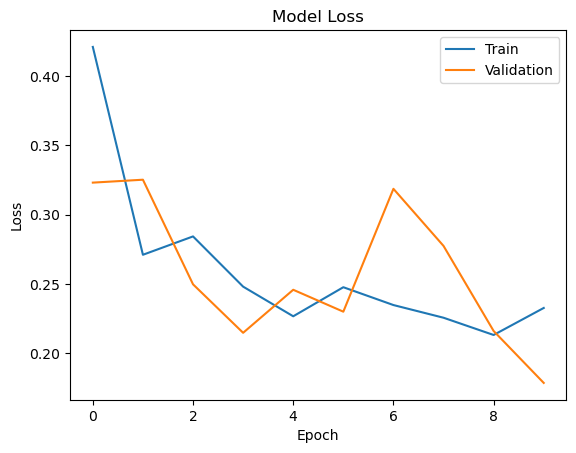

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
                                # TASK 4

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
predictions = model.predict(validation_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step


In [25]:
acc = accuracy_score(y_true, y_pred)
print("Validation Accuracy:", acc)

Validation Accuracy: 0.9127906976744186


In [26]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[  0   1  26]
 [  0   0  11]
 [  0   7 471]]


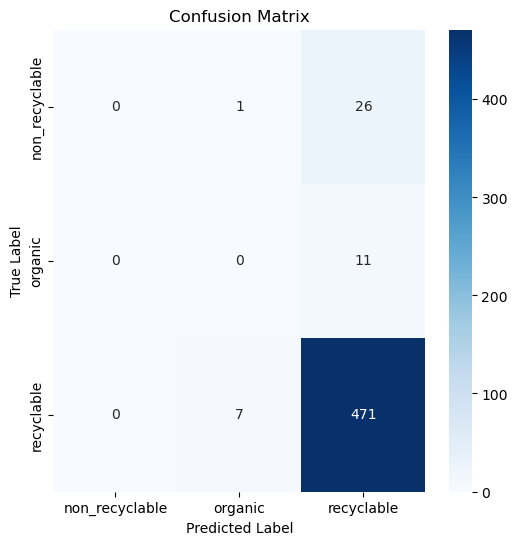

In [27]:
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


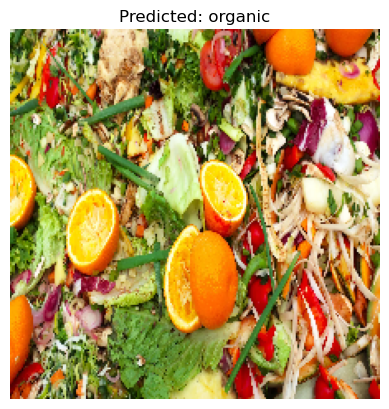

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


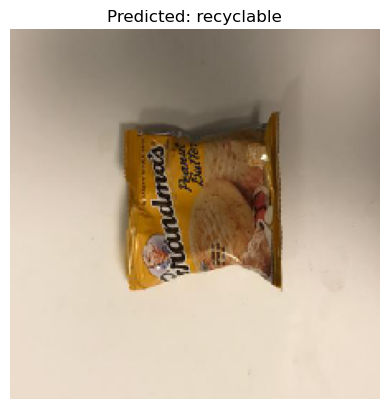

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


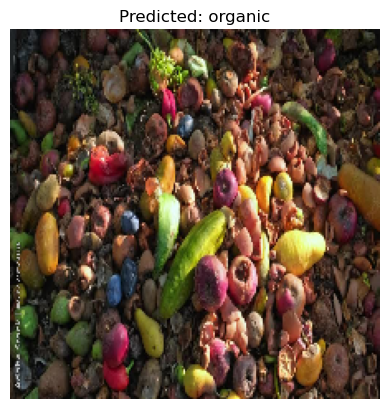

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


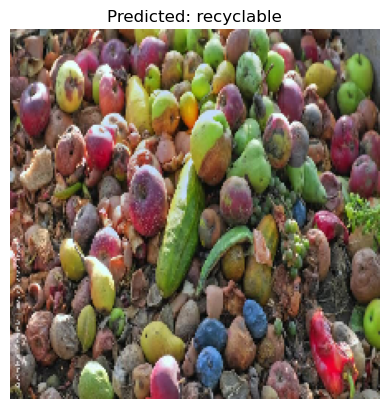

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


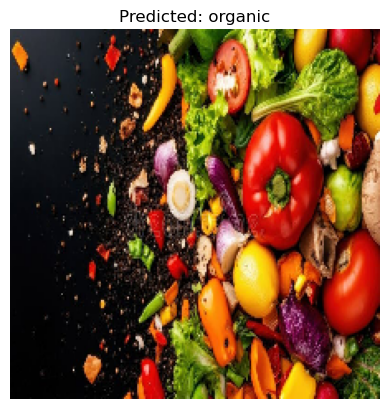

In [28]:
import random
from tensorflow.keras.preprocessing import image

class_labels = list(train_generator.class_indices.keys())

validation_path = "validation"

for i in range(5):

    class_name = random.choice(class_labels)
    img_folder = validation_path + "/" + class_name

    img_name = random.choice(os.listdir(img_folder))
    img_path = img_folder + "/" + img_name

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]

    plt.imshow(img)
    plt.title("Predicted: " + predicted_class)
    plt.axis("off")
    plt.show()

In [ ]:
                               # TASK 5

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [36]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,  # exclude final classification layers
    weights='imagenet'
)
base_model.trainable = False  # freeze base layers

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [37]:
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 classes
])

In [38]:
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model_tl.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 68s 972ms/step - accuracy: 0.8709 - loss: 0.4554 - val_accuracy: 0.9264 - val_loss: 0.3071
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9224 - loss: 0.2959 - val_accuracy: 0.9302 - val_loss: 0.2386
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9330 - loss: 0.2419 - val_accuracy: 0.9399 - val_loss: 0.1998
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9364 - loss: 0.2120 - val_accuracy: 0.9419 - val_loss: 0.1815
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 62s 950ms/step - accuracy: 0.9413 - loss: 0.1778 - val_accuracy: 0.9419 - val_loss: 0.1659
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9486 - loss: 0.1603 - val_accuracy: 0.9438 - val_loss: 0.1581
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9515 - loss: 0.1552 - val_accuracy: 0.9477 - val_loss: 0.1519
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9505 - loss: 0.1518 - val_accuracy: 0.9496 - val

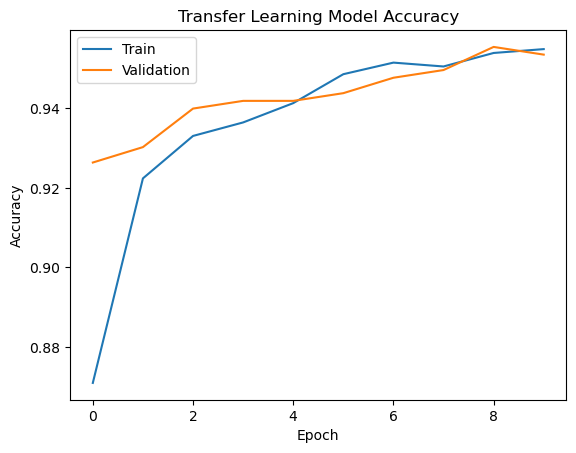

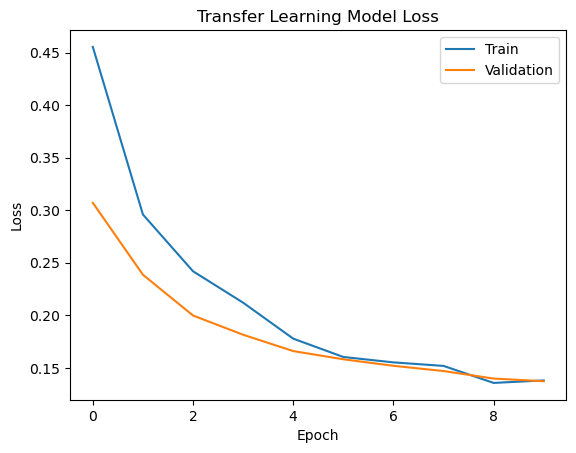

In [41]:
plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])
plt.title("Transfer Learning Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history_tl.history['loss'])
plt.plot(history_tl.history['val_loss'])
plt.title("Transfer Learning Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()